# Network Analysis
## Lab 3
### Centrality Measures

In this lab, we will use `igraph` to calculate different centrality measures in both examples and real-world networks. In particular, we explore the centrality measures discussed in class:
- Degree and weighted degree
- Closeness
- Betwenness
- Eigenvector
- Katz-Bonacich
- Page rank

In [1]:
# import packages
import igraph as ig
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

IGRAPH D-W- 7 9 --
+ attr: weight (e)
+ edges:
0->1 0->2 1->2 2->3 2->4 4->3 3->5 5->6 6->5


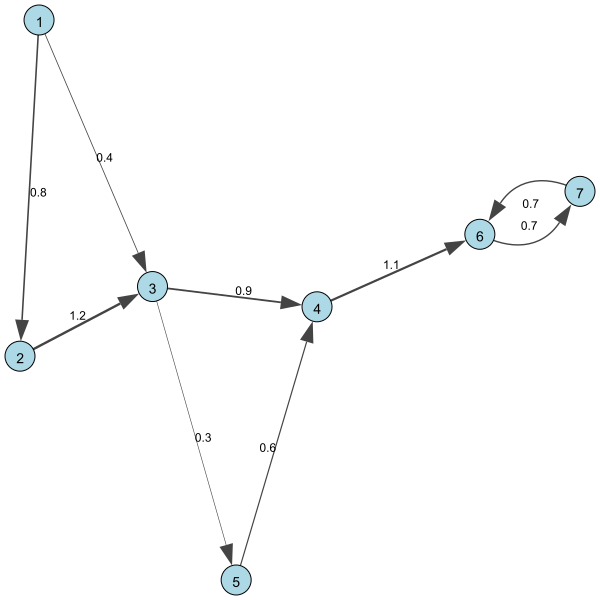

In [2]:
# --------------------------------------------
# Define the network as a graph
# --------------------------------------------
# igraph Convention: edge (j, i, w) means influence from j -> i with weight w
n_nodes = 7
edges = [
    (0, 1, 0.8),   # 1 -> 2
    (0, 2, 0.4),   # 1 -> 3
    (1, 2, 1.2),   # 2 -> 3
    (2, 3, 0.9),   # 3 -> 4
    (2, 4, 0.3),   # 3 -> 5
    (4, 3, 0.6),   # 5 -> 4
    (3, 5, 1.1),   # 4 -> 6
    (5, 6, 0.7),   # 6 -> 7
    (6, 5, 0.7)    # 7 -> 6 (cycle)
]

# --------------------------------------------
# Create igraph object and assign weight
# --------------------------------------------
G = ig.Graph(
    n=n_nodes,
    edges=[(j, i) for (j, i, w) in edges],
    directed=True
)
G.es["weight"] = [w for (j, i, w) in edges]
print(G)

# Visualize the graph
ig.plot(
    G,
    layout="fr",
    vertex_size=30,
    vertex_color="lightblue",
    vertex_label=[f"{i+1}" for i in range(n_nodes)],
    edge_width=[w * 2 for w in G.es["weight"]],
    edge_arrow_size=1.5,
    edge_label=G.es["weight"]
)

Adjacency matrix:
[[0.  0.8 0.4 0.  0.  0.  0. ]
 [0.  0.  1.2 0.  0.  0.  0. ]
 [0.  0.  0.  0.9 0.3 0.  0. ]
 [0.  0.  0.  0.  0.  1.1 0. ]
 [0.  0.  0.  0.6 0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.7]
 [0.  0.  0.  0.  0.  0.7 0. ]]


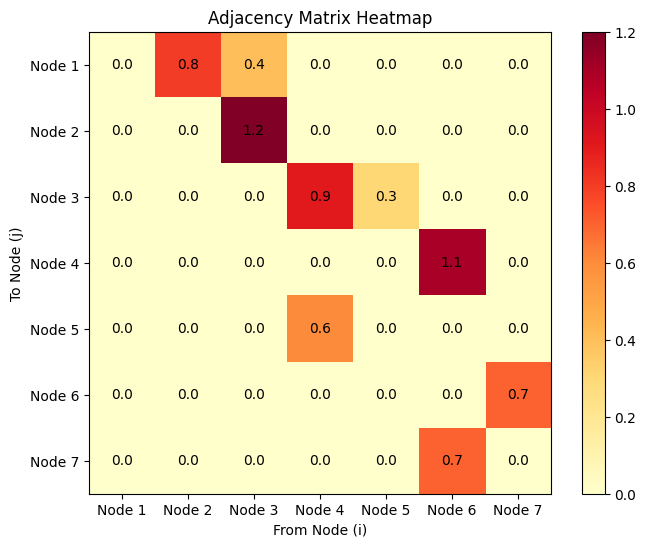

In [3]:
# --------------------------------------------
# Adjacency matrix
# --------------------------------------------
# A_ij = weight of edge i -> j
A = np.array(G.get_adjacency(attribute="weight").data)
print("Adjacency matrix:")
print(A)

plt.figure(figsize=(8, 6))
plt.imshow(A, cmap='YlOrRd')
plt.colorbar()
plt.xticks(ticks=np.arange(n_nodes), labels=[f"Node {i+1}" for i in range(n_nodes)])
plt.yticks(ticks=np.arange(n_nodes), labels=[f"Node {i+1}" for i in range(n_nodes)])
for i in range(n_nodes):
    for j in range(n_nodes):
        plt.text(j, i, np.round(A[i, j], 2), ha='center', va='center', color='black')
plt.title("Adjacency Matrix Heatmap")
plt.xlabel("From Node (i)")
plt.ylabel("To Node (j)")
plt.show()

In [4]:
# --------------------------------------------
# Degree centrality
# --------------------------------------------
in_degree = G.degree(mode="in")
out_degree = G.degree(mode="out")
weighted_in_degree = G.strength(mode="in", weights="weight")
weighted_out_degree = G.strength(mode="out", weights="weight")
print("In-degrees:", in_degree)
print("In-degree Strength:", weighted_in_degree)
print("Out-degrees:", out_degree)
print("Out-degree Strength:", weighted_out_degree)

# --------------------------------------------
# Closeness centrality
# --------------------------------------------
in_closeness = G.closeness(mode="in", weights="weight", normalized=True)
out_closeness = G.closeness(mode="out", weights="weight", normalized=True)

# --------------------------------------------
# Betweenness centrality
# --------------------------------------------
betweenness = G.betweenness(directed=True, weights="weight", normalized=True)

# --------------------------------------------
# Eigenvector centrality
# --------------------------------------------
eigenvector = G.eigenvector_centrality(
    directed=True,
    weights="weight"
)

# --------------------------------------------
# Katz (Bonacich) centrality — MANUAL
# c = 1 + beta * A c
# (I - beta A) c = 1
# --------------------------------------------
beta = 0.4
I = np.eye(n_nodes)
ones = np.ones(n_nodes)
katz = np.linalg.solve(I - beta * A, ones)

# --------------------------------------------
# PageRank centrality
# --------------------------------------------
# PageRank solves:
# p = (1 - d) * 1/n + d * P
# where P is the column-stochastic transition matrix
damping = 0.85
pagerank = G.pagerank(
    directed=True,
    damping=damping,
    weights="weight"
)

In-degrees: [0, 1, 2, 2, 1, 2, 1]
In-degree Strength: [0.0, 0.8, 1.6, 1.5, 0.3, 1.8, 0.7]
Out-degrees: [2, 1, 2, 1, 1, 1, 1]
Out-degree Strength: [1.2000000000000002, 1.2, 1.2, 1.1, 0.6, 0.7, 0.7]


C:\Users\smb32q\AppData\Local\Temp\ipykernel_5604\2379443350.py:27: RuntimeWarning: Some eigenvector centralities are nearly zero, indicating that the graph may not be (strongly) connected. Eigenvector centrality is not meaningful for disconnected graphs. Location: src/centrality/eigenvector.c:103
  eigenvector = G.eigenvector_centrality(


In [5]:
# --------------------------------------------
# Collect results in a table
# --------------------------------------------
df = pd.DataFrame({
    "In-degree": in_degree,
    "Out-degree": out_degree,
    "In-Closeness": in_closeness,
    "Out-Closeness": out_closeness,
    "Betweenness": betweenness,
    "Eigenvector": eigenvector,
    "Katz": katz,
    "PageRank": pagerank
})
df.index = [f"Node {i+1}" for i in range(n_nodes)]
print("\nCentrality measures:")
display(df)

# --------------------------------------------
# Compare rankings
# --------------------------------------------
rankings = df.rank(ascending=False)
print("\nRankings (1 = highest):")
display(rankings)


Centrality measures:


,In-degree,Out-degree,In-Closeness,Out-Closeness,Betweenness,Eigenvector,Katz,PageRank
Node 1,0,2,NaN,0.689655,0.000000,-0.000000e+00,1.867671,0.021429
Node 2,1,1,1.250000,0.420168,0.000000,-0.000000e+00,1.838272,0.033571
Node 3,2,2,1.250000,0.677966,0.190476,0.000000e+00,1.746400,0.056036
Node 4,2,1,0.816327,0.689655,0.190476,6.280370e-16,1.611111,0.085487
Node 5,1,1,1.200000,0.638298,0.107143,7.850462e-17,1.386667,0.033336
Node 6,2,1,0.540541,1.428571,0.119048,1.000000e+00,1.388889,0.404709
Node 7,1,1,0.410959,1.428571,0.000000,1.000000e+00,1.388889,0.365432



Rankings (1 = highest):


,In-degree,Out-degree,In-Closeness,Out-Closeness,Betweenness,Eigenvector,Katz,PageRank
Node 1,7.0,1.5,NaN,3.5,6.0,6.0,1.0,7.0
Node 2,5.0,5.0,1.5,7.0,6.0,6.0,2.0,5.0
Node 3,2.0,1.5,1.5,5.0,1.5,6.0,3.0,4.0
Node 4,2.0,5.0,4.0,3.5,1.5,3.0,4.0,3.0
Node 5,5.0,5.0,3.0,6.0,4.0,4.0,7.0,6.0
Node 6,2.0,5.0,5.0,1.5,3.0,1.0,6.0,1.0
Node 7,5.0,5.0,6.0,1.5,6.0,2.0,5.0,2.0


## Real-world network: Karate club

Number of nodes: 34
Number of edges: 78


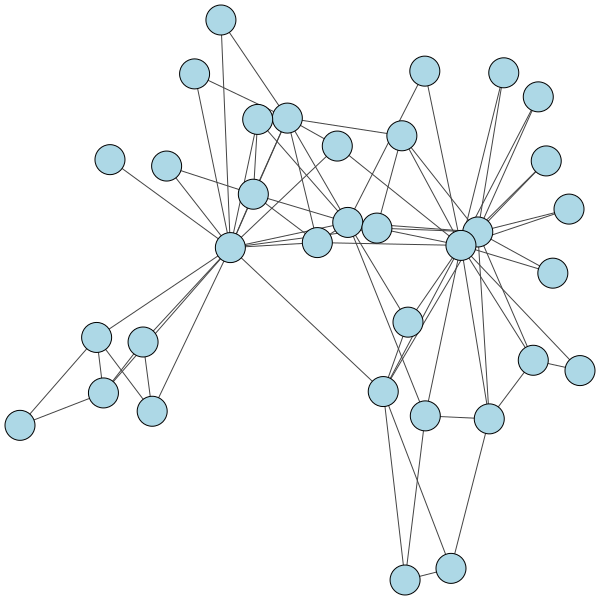

In [6]:
# --------------------------------------------
# 1. Load the Karate Club network
# --------------------------------------------
Gk = ig.Graph.Famous("Zachary")
print(f"Number of nodes: {Gk.vcount()}")
print(f"Number of edges: {Gk.ecount()}")
ig.plot(
    Gk,
    layout="fr",
    vertex_size=30,
    vertex_color="lightblue"
)

In [7]:

# --------------------------------------------
# 2. Compute PageRank
# --------------------------------------------
damping = 0.85
pagerank_karate = Gk.pagerank(
    directed=False,   # Karate network is undirected
    damping=damping
)

# --------------------------------------------
# 3. Other centralities for comparison
# --------------------------------------------
degree = Gk.degree()
betweenness = Gk.betweenness(normalized=True)
eigenvector = Gk.eigenvector_centrality()

# --------------------------------------------
# 4. Collect results
# --------------------------------------------
df_karate = pd.DataFrame({
    "Degree": degree,
    "Betweenness": betweenness,
    "Eigenvector": eigenvector,
    "PageRank": pagerank_karate
})

df_karate.index = [f"Node {i+1}" for i in range(Gk.vcount())]

# print("\nCentrality measures (Karate network):")
# display(df_karate)

# --------------------------------------------
# 5. Rankings
# --------------------------------------------
rankings_karate = df_karate.rank(ascending=False)
# print("\nRankings (1 = highest):")
# display(rankings_karate)

# --------------------------------------------
# 6. Top nodes by Eigenvector
# --------------------------------------------
print("\nTop 5 nodes by Degree:")
display(df_karate.sort_values("PageRank", ascending=False).head())


Top 5 nodes by Degree:


,Degree,Betweenness,Eigenvector,PageRank
Node 34,17,0.286188,1.000000,0.100919
Node 1,16,0.411892,0.952132,0.096997
Node 33,12,0.136703,0.826659,0.071693
Node 3,10,0.135206,0.849554,0.057079
Node 2,9,0.050764,0.712335,0.052877


## Real-world network: US 2002 IO output

dict_keys(['__header__', '__version__', '__globals__', 'CC02'])
(417, 417)
78990


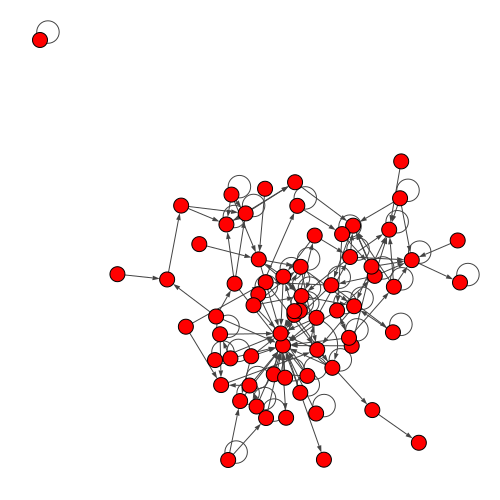

In [8]:
# Load data as a Matlab .mat file
from scipy.io import loadmat

# Load .mat file
mat_data = loadmat('IO2002_data.mat')
# mat_data is a dictionary where keys are variable names
print(mat_data.keys())  # See what variables are in the file

# Access specific matrix/variable
IO_matrix = mat_data['CC02']
print(IO_matrix.shape)
print((IO_matrix > 0).sum())  # Column sums (total output)

# --------------------------------------------
# Parameters
# --------------------------------------------
threshold = 0.05      # threshold for IO links
directed = True

# --------------------------------------------
# Threshold IO matrix and build network
# --------------------------------------------
# Binary adjacency after thresholding
A_binary = (IO_matrix > threshold).astype(int)
n = A_binary.shape[0]
rowsum = A_binary.sum(axis=1)
mask = rowsum >= 3
A_binary = A_binary[mask][:, mask]
rowsum = rowsum[mask]
n = A_binary.shape[0]

# Build igraph object
edges = [(j, i) for i in range(n) for j in range(n) if A_binary[i, j] == 1]
G_bin = ig.Graph(
    n=n,
    edges=edges,
    directed=directed
)

# --------------------------------------------
# Unweighted in- and out-degrees
# --------------------------------------------
in_degree = G_bin.degree(mode="in")
out_degree = G_bin.degree(mode="out")

# ------------------------------
# Visualize thresholded network
# ------------------------------
ig.plot(
    G_bin,
    layout="kamada_kawai",
    vertex_size=15,
    edge_arrow_size=0.5,
    bbox=(500, 500),
    margin=40
)

[np.float64(0.030452909442899145), np.float64(0.00016368803592226115), np.float64(0.0), np.float64(0.09706535814041714), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0006999183564437231), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(4.954116120546631e-06), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(5.63851931114264e-05), np.float64(0.0), np.float64(0.0), np.float64(0.009813866588048769), np.float64(2.9431368761517256e-05), np.float64(0.0685711870798328), np.float64(0.012382480206958929), np.float64(0.0023498871861456824), np.float64(0.0), np.float64(0.02222175671070196), np.float64(0.00015879368428445536), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0069389410867189295), np.floa

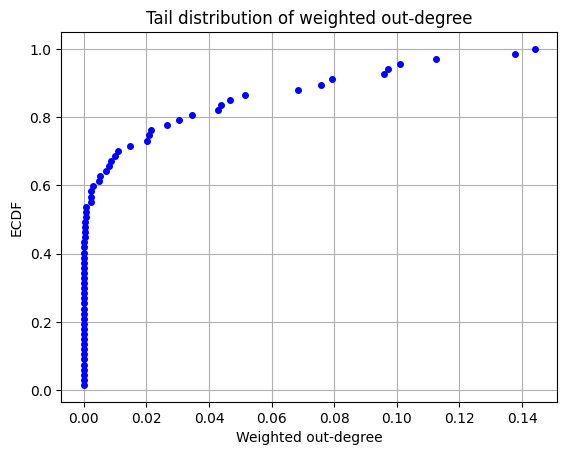

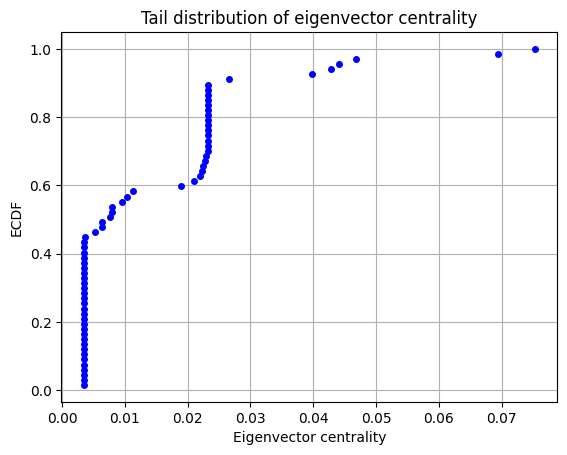

In [9]:
# --------------------------------------------
# Weighted in- and out-degrees (strength)
# --------------------------------------------
# Build weighted graph (same edges, original weights)
weights = [IO_matrix[i, j] for (j, i) in edges]
print(weights)
G_w = ig.Graph(
    n=n,
    edges=edges,
    directed=directed
)
G_w.es["weight"] = weights
weighted_in = G_w.strength(mode="in", weights="weight")
weighted_out = G_w.strength(mode="out", weights="weight")
print("Weighted out-degrees:", weighted_out)

# --------------------------------------------
# Plot 1 - ECDF of weighted out-degree
# --------------------------------------------
x = np.sort(weighted_out)
ecdf = np.arange(1, n + 1) / n

plt.figure()
plt.plot(x, ecdf, 'bo', markersize=4)
plt.xlabel("Weighted out-degree")
plt.ylabel("ECDF")
plt.title("Tail distribution of weighted out-degree")
plt.grid(True)
plt.show()

# --------------------------------------------
# Eigenvector centrality
# --------------------------------------------
eigenvector = G_w.pagerank(
    damping=0.85,
    directed=True,
    weights="weight"
)

# --------------------------------------------
# Plot 2 - ECDF of eigenvector centrality
# --------------------------------------------
x_ev = np.sort(eigenvector)
ecdf_ev = np.arange(1, n + 1) / n

plt.figure()
plt.plot(x_ev, ecdf_ev, 'bo', markersize=4)
plt.xlabel("Eigenvector centrality")
plt.ylabel("ECDF")
plt.title("Tail distribution of eigenvector centrality")
plt.grid(True)
plt.show()